In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

# Reproduzierbarkeit
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
except ImportError:
    tf = None
    print("Hinweis: TensorFlow nicht installiert. Bitte: pip install tensorflow (oder tensorflow-macos tensorflow-metal auf Apple Silicon)")

DATA_PATH = Path("data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("data.csv nicht gefunden. Bitte zuerst das Erzeugungs-Notebook laufen lassen.")

X = []
y = []
with open(DATA_PATH) as f:
    reader = csv.DictReader(f)
    for row in reader:
        X.append([float(row['x1']), float(row['x2'])])
        y.append(int(row['label']))
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)
print("Form X", X.shape, "Form y", y.shape)
print("Erste 5 Punkte:")
print(X[:5], y[:5])

# Datensplit (Train/Validation/Test)
indices = np.arange(len(X))
# moderner Generator statt legacy shuffle
rng = np.random.default_rng(SEED)
rng.shuffle(indices)
X = X[indices]
y = y[indices]

n_total = len(X)
n_train = int(0.6 * n_total)
n_val = int(0.2 * n_total)
# Rest test
X_train = X[:n_train]
y_train = y[:n_train]
X_val = X[n_train:n_train+n_val]
y_val = y[n_train:n_train+n_val]
X_test = X[n_train+n_val:]
y_test = y[n_train+n_val:]
print(f"Split Größen -> Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


/Users/aledal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Form X (400, 2) Form y (400,)
Erste 5 Punkte:
[[ 0.63154763  0.10007107]
 [ 0.04607517  0.2711424 ]
 [-0.32732496 -0.6597334 ]
 [ 0.76234704  0.46347746]
 [ 0.4145488   0.07853215]] [1 0 1 1 0]
Split Größen -> Train: 240, Val: 80, Test: 80


# Neuronale Netze mit TensorFlow: Klassifikation eines Ring-Datensatzes

Dieses Notebook zeigt Schritt für Schritt, wie ein neuronales Netz einen *nicht linear trennbaren* 2D-Datensatz (Ring: innen Klasse 0, außen Klasse 1) lernt. Alle Konzepte werden bewusst einfach erklärt. Falls TensorFlow noch fehlt, bitte installieren (siehe Hinweise weiter unten).

## Lernziele
Nach dem Durcharbeiten solltest du verstehen:
- Warum lineare Modelle für nichtlineare Muster unzureichend sind.
- Wie ein mehrschichtiges Netzwerk (Hidden Layers + Aktivierungsfunktionen) eine nichtlineare Entscheidungsgrenze lernt.
- Was die Metriken Loss, Accuracy, Precision, Recall und F1 bedeuten.
- Wie man Trainings-, Validierungs- und Testdaten trennt und warum das wichtig ist.
- Wie EarlyStopping Überanpassung (Overfitting) reduziert.

## Kurzübersicht der Schritte
1. Daten laden & vorbereiten (Train/Val/Test Split)
2. Lineares Basis-Modell (Grenzen aufzeigen)
3. Neuronales Netz mit ReLU + EarlyStopping
4. Trainingsverlauf analysieren (Loss/Accuracy)
5. Entscheidungsflächen vergleichen
6. Forward-Pass eines Beispielpunkts (Zwischenlayer-Ausgaben)
7. Qualitätsmetriken (Konfusionsmatrix, Precision, Recall, F1)
8. Aktivierungsvergleich (ReLU vs. Tanh)
9. Konzepte zu Overfitting & Regularisierung
10. Übungsaufgaben für eigene Experimente

> Hinweis: Alle Codeabschnitte sind kommentiert; ändere Parameter und beobachte den Effekt.

---

In [2]:
def plot_decision_surface(model, title, resolution=200):
    xx = np.linspace(-1,1,resolution)
    yy = np.linspace(-1,1,resolution)
    XX, YY = np.meshgrid(xx, yy)
    grid = np.vstack([XX.ravel(), YY.ravel()]).T
    probs = model.predict(grid, verbose=0).reshape(XX.shape)
    plt.contourf(XX, YY, probs, levels=20, cmap='RdBu', alpha=0.6)
    plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], s=8, c='black', alpha=0.4, label='Train 0')
    plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], s=8, c='yellow', edgecolors='black', alpha=0.6, label='Train 1')
    plt.title(title)
    plt.axis('equal')
    plt.legend(loc='upper right', fontsize=8)


## 1. Funktion: Entscheidungsfläche plotten
Diese Hilfsfunktion erzeugt eine farbcodierte Karte der vorhergesagten Wahrscheinlichkeit (Ausgabe des Modells) und legt die Trainingspunkte darüber. So sieht man direkt, ob das Modell eine Kreisform lernt oder nur eine gerade Linie.

In [3]:
def plot_decision_surface(model, title, resolution=200):
    xx = np.linspace(-1,1,resolution)
    yy = np.linspace(-1,1,resolution)
    XX, YY = np.meshgrid(xx, yy)
    grid = np.vstack([XX.ravel(), YY.ravel()]).T
    probs = model.predict(grid, verbose=0).reshape(XX.shape)
    plt.contourf(XX, YY, probs, levels=20, cmap='RdBu', alpha=0.6)
    plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], s=8, c='black', alpha=0.4, label='Train 0')
    plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], s=8, c='yellow', edgecolors='black', alpha=0.6, label='Train 1')
    plt.title(title)
    plt.axis('equal')
    plt.legend(loc='upper right', fontsize=8)


## 2. Lineares Basis-Modell (mit Validierung/Test)
Ein lineares Modell (logistische Regression / ein einzelner Dense-Layer mit Sigmoid) kann nur *lineare* Trennflächen (Geraden in 2D) bilden. Da unser Ziel die Trennung eines Kreises ist, erwarten wir begrenzte Leistung.

Beobachte nach dem Training:
- Unterschied zwischen Train- und Val-Accuracy (Generalisation)
- Form der Entscheidungsfläche (verzerrt, keine echte Kreisform)

/Users/aledal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Linear Modell Zusammenfassung:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

Finale Linear Accuracy (Train): 0.38333332538604736
Finale Linear Accuracy (Val): 0.4000000059604645
Linear Test Loss=0.7008 Test Acc=0.3500


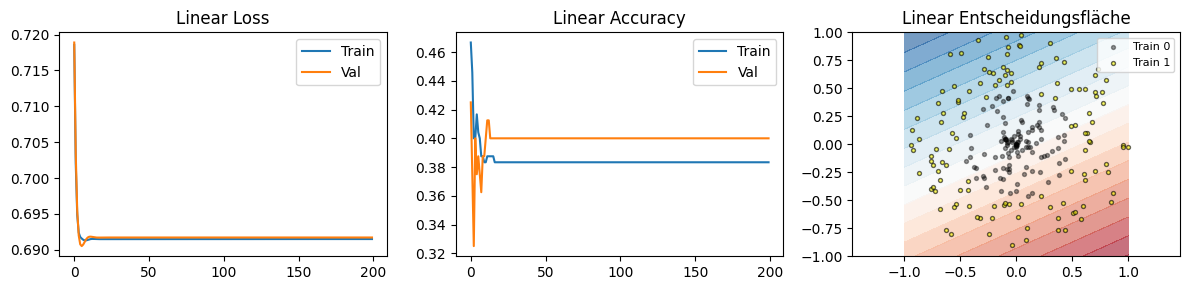

In [4]:
if tf is not None:
    from tensorflow import keras
    from tensorflow.keras import layers

    linear_model = keras.Sequential([
        layers.Dense(1, activation='sigmoid', input_shape=(2,))
    ])
    linear_model.compile(optimizer=keras.optimizers.Adam(0.05),
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

    linear_hist = linear_model.fit(X_train, y_train,
                                   validation_data=(X_val, y_val),
                                   epochs=200, verbose=0)
    print("Linear Modell Zusammenfassung:")
    linear_model.summary()
    print("Finale Linear Accuracy (Train):", linear_hist.history['accuracy'][-1])
    print("Finale Linear Accuracy (Val):", linear_hist.history['val_accuracy'][-1])

    lin_test_loss, lin_test_acc = linear_model.evaluate(X_test, y_test, verbose=0)
    print(f"Linear Test Loss={lin_test_loss:.4f} Test Acc={lin_test_acc:.4f}")

    plt.figure(figsize=(12,3))
    plt.subplot(1,3,1)
    plt.plot(linear_hist.history['loss'], label='Train')
    plt.plot(linear_hist.history['val_loss'], label='Val')
    plt.title('Linear Loss')
    plt.legend()
    plt.subplot(1,3,2)
    plt.plot(linear_hist.history['accuracy'], label='Train')
    plt.plot(linear_hist.history['val_accuracy'], label='Val')
    plt.title('Linear Accuracy')
    plt.legend()
    plt.subplot(1,3,3)
    plot_decision_surface(linear_model, 'Linear Entscheidungsfläche')
    plt.tight_layout()
    plt.show()
else:
    print("TensorFlow nicht installiert – überspringe lineares Modell. Bitte installieren und Notebook neu starten.")


## 3. Neuronales Netz (mit EarlyStopping)
Durch zwei versteckte Schichten mit ReLU werden *nichtlineare Transformationen* gelernt. Dadurch kann die finale Sigmoid-Ausgabe eine gekrümmte Entscheidungsfläche bilden.

Elemente:
- ReLU: max(0, x) verhindert Sättigung vieler Neuronen und ermöglicht Stückweise-Linearisierung.
- EarlyStopping: Stoppt vorzeitig, wenn sich der Validierungs-Loss nicht mehr verbessert (Schutz vor Overfitting).

In [5]:
if tf is not None:
    nn_model = keras.Sequential([
        layers.Dense(8, activation='relu', input_shape=(2,)),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    nn_model.compile(optimizer=keras.optimizers.Adam(0.01),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

    early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

    history = nn_model.fit(X_train, y_train,
                           validation_data=(X_val, y_val),
                           epochs=800, callbacks=[early], verbose=0)
    print("NN Modell Zusammenfassung:")
    nn_model.summary()
    print("Finale NN Accuracy (Train):", history.history['accuracy'][-1])
    print("Finale NN Accuracy (Val):", history.history['val_accuracy'][-1])

    nn_test_loss, nn_test_acc = nn_model.evaluate(X_test, y_test, verbose=0)
    print(f"NN Test Loss={nn_test_loss:.4f} Test Acc={nn_test_acc:.4f}")
else:
    print("TensorFlow nicht installiert – überspringe NN Training.")


NN Modell Zusammenfassung:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 317 (1.24 KB)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 212 (852.00 B)

Finale NN Accuracy (Train): 1.0
Finale NN Accuracy (Val): 0.9750000238418579
NN Test Loss=0.0724 Test Acc=0.9750


## 4. Trainingsergebnisse (Loss & Accuracy)
Interpretation:
- Loss (binary_crossentropy) misst die Abweichung zwischen vorhergesagter Wahrscheinlichkeit und Zielklasse.
- Sinkender Loss + steigende Accuracy deuten auf Lernfortschritt.
- Achte auf eine Überlappung der Kurven (Train vs. Val). Starker Auseinanderlauf = Overfitting.

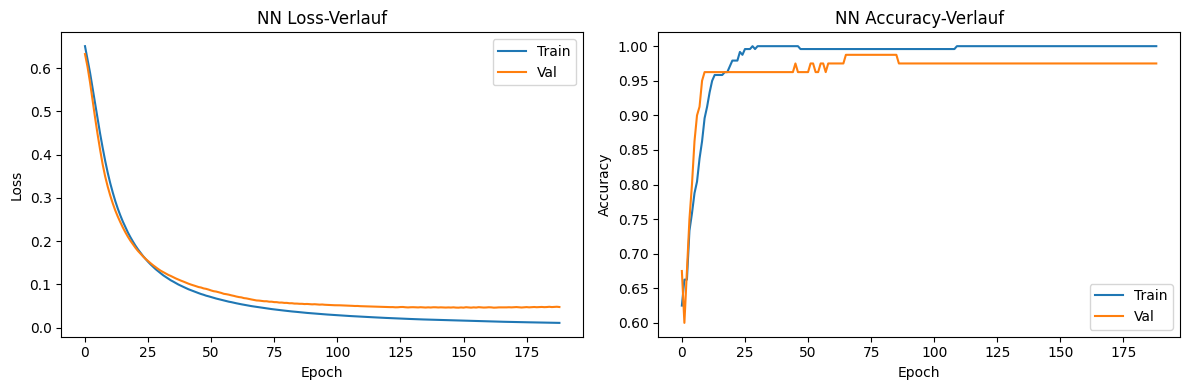

In [6]:
if tf is not None and 'history' in globals():
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history.get('loss', []), label='Train')
    plt.plot(history.history.get('val_loss', []), label='Val')
    plt.title('NN Loss-Verlauf')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history.get('accuracy', []), label='Train')
    plt.plot(history.history.get('val_accuracy', []), label='Val')
    plt.title('NN Accuracy-Verlauf')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Kein NN Verlauf – TensorFlow fehlt oder history nicht vorhanden.")


## 5. Entscheidungsfläche Vergleich (Test)
Hier vergleichen wir die gelernten Entscheidungsflächen. Das neuronale Netz sollte eine kreisähnliche Grenze lernen, das lineare Modell nur eine approximierende Gerade.

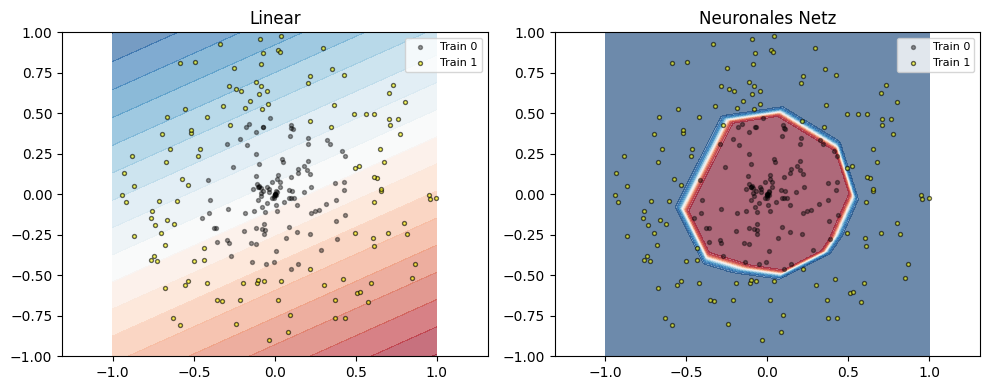

In [7]:
if tf is not None and ('linear_model' in globals() or 'nn_model' in globals()):
    plt.figure(figsize=(10,4))
    if 'linear_model' in globals():
        plt.subplot(1,2,1)
        plot_decision_surface(linear_model, 'Linear')
        if 'nn_model' in globals():
            plt.subplot(1,2,2)
            plot_decision_surface(nn_model, 'Neuronales Netz')
    elif 'nn_model' in globals():
        plot_decision_surface(nn_model, 'Neuronales Netz')
    plt.tight_layout()
    plt.show()
else:
    print("Keine Entscheidungsflächen ohne trainierte Modelle.")


## 6. Forward-Pass eines Beispielpunkts
Wir geben einen einzelnen Punkt durch das Netzwerk und zeigen die Aktivierungen der Hidden Layers. Jede Zahl ist ein *Feature*, das das Netz intern konstruiert. Zusammengesetzt entsteht daraus die finale Klassifikationswahrscheinlichkeit.

In [8]:
if tf is not None:
    example = np.array([[0.3, 0.3]], dtype=np.float32)
    intermediate_model = keras.Model(nn_model.input, [layer.output for layer in nn_model.layers])
    activations = intermediate_model.predict(example, verbose=0)
    print("Eingabe:", example)
    for i, act in enumerate(activations[:-1]):
        print(f"Layer {i} (Hidden) Ausgabe Shape {act.shape}: {act}")
    print("Output Wahrscheinlichkeit Klasse 1:", activations[-1])
else:
    print("Forward-Pass Beispiel nicht möglich ohne TensorFlow.")


AttributeError: The layer sequential_1 has never been called and thus has no defined input.

## 7. Konfusionsmatrix & Kennzahlen (Test Set)
Begriffe:
- TP (True Positive): Modell sagt 1 und Klasse ist 1
- TN (True Negative): Modell sagt 0 und Klasse ist 0
- FP (False Positive): Modell sagt 1, Klasse ist aber 0
- FN (False Negative): Modell sagt 0, Klasse ist aber 1

Metriken:
- Precision = TP / (TP + FP)  (Wie verlässlich sind positive Vorhersagen?)
- Recall = TP / (TP + FN)     (Wie viele echte Positive werden gefunden?)
- F1 = harmonisches Mittel aus Precision und Recall (Balance-Maß)

Warum nicht nur Accuracy? Bei unausgeglichenen Klassen oder asymmetrischen Kosten liefern Precision & Recall ein differenzierteres Bild.

In [ ]:
if tf is not None:
    nn_probs_test = nn_model.predict(X_test, verbose=0)
    nn_pred_test = (nn_probs_test >= 0.5).astype(int).ravel()
    TP = int(np.sum((nn_pred_test==1) & (y_test==1)))
    TN = int(np.sum((nn_pred_test==0) & (y_test==0)))
    FP = int(np.sum((nn_pred_test==1) & (y_test==0)))
    FN = int(np.sum((nn_pred_test==0) & (y_test==1)))
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    print("Konfusionsmatrix (Test):")
    print(f"TP={TP} TN={TN} FP={FP} FN={FN}")
    print(f"Precision={precision:.4f} Recall={recall:.4f} F1={f1:.4f}")
else:
    print("Konfusionsmatrix nicht berechenbar ohne TensorFlow.")


## 8. Vergleich verschiedener Aktivierungen (optional)
ReLU vs. Tanh:
- ReLU: Schnellere Konvergenz, keine Sättigung im positiven Bereich, kann aber "tote" Neuronen bekommen.
- Tanh: Symmetrisch um 0, kann bei kleinen Netzen etwas glattere Entscheidung liefern, aber saturiert stärker.

Teste selbst weitere: `elu`, `selu`, `gelu` (erfordert ggf. zusätzliche Imports).

In [ ]:
if tf is not None:
    act_results = {}
    for act in ['relu','tanh']:
        model_tmp = keras.Sequential([
            layers.Dense(8, activation=act, input_shape=(2,)),
            layers.Dense(8, activation=act),
            layers.Dense(1, activation='sigmoid')
        ])
        model_tmp.compile(optimizer=keras.optimizers.Adam(0.01),
                          loss='binary_crossentropy',
                          metrics=['accuracy'])
        h = model_tmp.fit(X_train, y_train, validation_data=(X_val,y_val), epochs=150, verbose=0)
        test_loss, test_acc = model_tmp.evaluate(X_test, y_test, verbose=0)
        act_results[act] = (h.history['val_accuracy'][-1], test_acc)

    print("Aktivierungsvergleich (Val_Acc, Test_Acc):")
    for act,(val_acc,test_acc) in act_results.items():
        print(f"{act}: Val={val_acc:.4f} Test={test_acc:.4f}")
else:
    print("Aktivierungsvergleich nicht möglich ohne TensorFlow.")


## 9. Regularisierung & Overfitting (erweitert)
Konzepte:
- Overfitting: Modell passt sich zu stark an Trainingsdaten (Val-Leistung schlechter)
- Underfitting: Modell ist zu simpel, sowohl Train als auch Val schlecht.

Strategien (nur beschrieben, kein Code blockiert das Notebook):
- EarlyStopping: Stoppt vor unnötigen weiteren Epochen.
- Dropout: Zufälliges Ausschalten von Neuronen -> robustere Merkmalskombinationen.
- L2-Regularisierung: Bestraft große Gewichte -> glattere Entscheidung.
- Datenvergrößerung: Mehr Beispiele senken Varianz.

Beispiel (selbst ausprobieren):
```
model = keras.Sequential([
    layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-3), input_shape=(2,)),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-3)),
    layers.Dense(1, activation='sigmoid')
])
```

Vergleiche Val-Loss & F1 vor und nach Hinzufügen dieser Techniken.

## 10. Zusammenfassung
- Lineares Modell: Unzureichend für Kreis-Trennung.
- NN mit Hidden Layers + ReLU: Lernt nichtlineare Grenze erfolgreich.
- Validierung & Test zeigen echte Generalisierung.
- Metriken jenseits der Accuracy sind wichtig für Qualitätsbewertung.
- Aktivierungsfunktionen beeinflussen Lernverhalten.
- Regularisierung verhindert Überanpassung.

### Übungsaufgaben (Vertiefung)
1. Verändere Hidden-Neuronen (4, 16, 32) und vergleiche F1.
2. Füge `Dropout(0.5)` zwischen die Hidden-Layer ein und beobachte Val-Loss.
3. Ersetze das Output-Sigmoid durch 2-Neuronen-Softmax (Dense(2, activation='softmax')) und nutze `sparse_categorical_crossentropy`.
4. Reduziere Lernrate von 0.01 auf 0.001 – konvergiert stabiler oder langsamer?
5. Entferne EarlyStopping und trainiere volle 800 Epochen – wann beginnt Overfitting?
6. Berechne AUC (ROC) mit `keras.metrics.AUC()` für zusätzliche Bewertung.

Viel Erfolg beim weiteren Experimentieren – ändere Parameter und beobachte deren Einfluss!
